**Import Library**

In [1]:
import os
import shutil
import pathlib
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

from PIL import Image
from google.colab import drive

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


**Data** **Preparation**

In [2]:
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    as_supervised=True,
    with_info=True
)

class_names = ['Kucing', 'Anjing']
num_classes = len(class_names)

print("Dataset berhasil dimuat")
print("Nama Dataset :", "cats_vs_dogs")
print("Nama Kelas   :", class_names)
print("Jumlah Kelas :", num_classes)
print("Total Data   :", ds_info.splits['train'].num_examples)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.HVPN9B_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Dataset berhasil dimuat
Nama Dataset : cats_vs_dogs
Nama Kelas   : ['Kucing', 'Anjing']
Jumlah Kelas : 2
Total Data   : 23262


**Data Loading**

In [3]:
IMG_SIZE = 150
BATCH_SIZE = 32

print("Ukuran gambar :", IMG_SIZE, "x", IMG_SIZE)
print("Batch size    :", BATCH_SIZE)

print("Data Training   :", len(ds_train), "data")
print("Data Validation :", len(ds_val), "data")
print("Data Testing    :", len(ds_test), "data")

Ukuran gambar : 150 x 150
Batch size    : 32
Data Training   : 16283 data
Data Validation : 3490 data
Data Testing    : 3489 data


**Data Preprocessing**

In [4]:
# SPLIT DATASET

print("Data Training   : 70%")
print("Data Validation : 15%")
print("Data Testing    : 15%")

Data Training   : 70%
Data Validation : 15%
Data Testing    : 15%


In [5]:
# RESIZE DAN NORMALISASI

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

In [6]:
# Membuat Train, Validation, dan Test Data
train_data = ds_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE)
val_data = ds_val.map(preprocess).batch(BATCH_SIZE)
test_data = ds_test.map(preprocess).batch(BATCH_SIZE)

print("Preprocessing selesai")
print("train_data, val_data, dan test_data siap digunakan")

Preprocessing selesai
train_data, val_data, dan test_data siap digunakan


**Visualisasi Dataset**

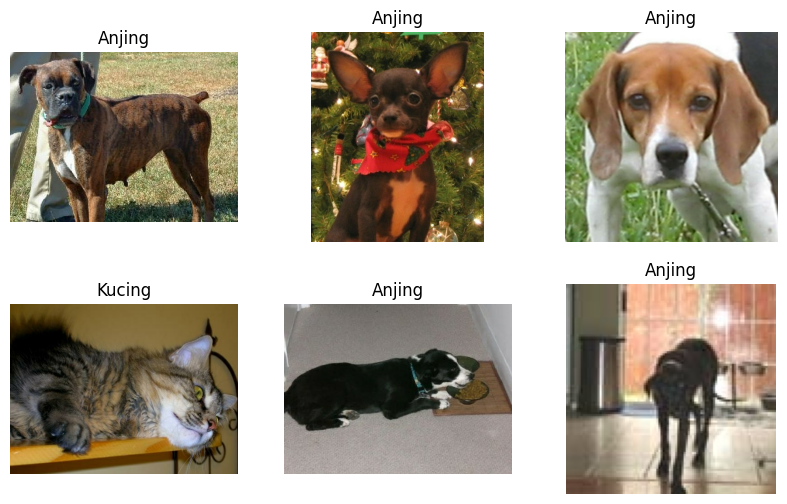

In [7]:
plt.figure(figsize=(10, 6))

for i, (image, label) in enumerate(ds_train.take(6)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[label.numpy()])
    plt.axis("off")

plt.show()

**Modelling CNN**

In [8]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

print("Model CNN berhasil dibuat")
model.summary()

Model CNN berhasil dibuat


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model CNN berhasil dikompilasi")

Model CNN berhasil dikompilasi


In [10]:
callbacks = [

    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7
    ),

    ModelCheckpoint(
        "best_model.keras",
        monitor='val_accuracy',
        save_best_only=True
    )

]

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks
)

print("Training model CNN selesai")

Epoch 1/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 812s 2s/step - accuracy: 0.5538 - loss: 0.6917 - val_accuracy: 0.5722 - val_loss: 0.6724 - learning_rate: 0.0010
Epoch 2/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 842s 2s/step - accuracy: 0.6448 - loss: 0.6347 - val_accuracy: 0.6387 - val_loss: 0.6407 - learning_rate: 0.0010
Epoch 3/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 777s 2s/step - accuracy: 0.7341 - loss: 0.5326 - val_accuracy: 0.7656 - val_loss: 0.4974 - learning_rate: 0.0010
Epoch 4/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 767s 2s/step - accuracy: 0.7814 - loss: 0.4608 - val_accuracy: 0.7725 - val_loss: 0.4901 - learning_rate: 0.0010
Epoch 5/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 820s 2s/step - accuracy: 0.8147 - loss: 0.4062 - val_accuracy: 0.8080 - val_loss: 0.4292 - learning_rate: 0.0010
Training model CNN selesai


**Evaluasi dan Visualisasi**

In [12]:
train_loss, train_acc = model.evaluate(train_data)
val_loss, val_acc = model.evaluate(val_data)
test_loss, test_acc = model.evaluate(test_data)

print("Training Accuracy   :", train_acc)
print("Validation Accuracy :", val_acc)
print("Testing Accuracy    :", test_acc)

print("Training Loss       :", train_loss)
print("Validation Loss     :", val_loss)
print("Testing Loss        :", test_loss)

509/509 ━━━━━━━━━━━━━━━━━━━━ 226s 441ms/step - accuracy: 0.8680 - loss: 0.3114
110/110 ━━━━━━━━━━━━━━━━━━━━ 47s 428ms/step - accuracy: 0.8080 - loss: 0.4292
110/110 ━━━━━━━━━━━━━━━━━━━━ 58s 526ms/step - accuracy: 0.8212 - loss: 0.4121
Training Accuracy   : 0.8679604530334473
Validation Accuracy : 0.8080229163169861
Testing Accuracy    : 0.8211522102355957
Training Loss       : 0.3113764524459839
Validation Loss     : 0.42922455072402954
Testing Loss        : 0.4121238589286804


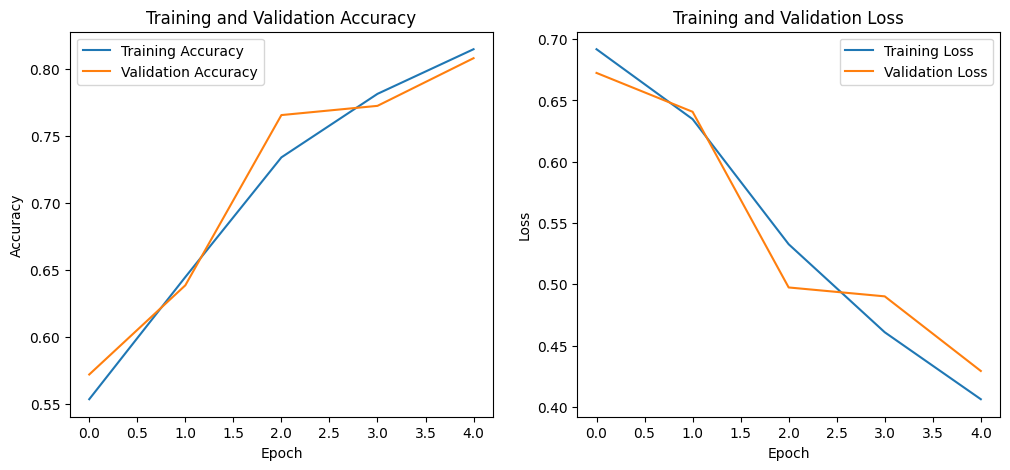

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

**Inference (Prediksi)**

Saving cing.avif to cing (2).avif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


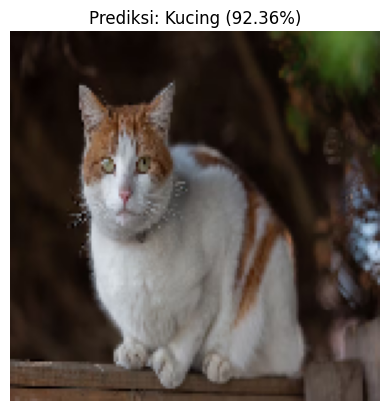

Nilai Output : 0.07639558
Prediksi     : Kucing
Confidence   : 92.36%


In [34]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():

    img = load_img(filename, target_size=(IMG_SIZE, IMG_SIZE), color_mode="rgb")
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    prob = prediction[0][0]

    if prob >= 0.5:
        predicted_class = "Anjing"
        confidence = prob * 100
    else:
        predicted_class = "Kucing"
        confidence = (1 - prob) * 100

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediksi: {predicted_class} ({confidence:.2f}%)")
    plt.show()

    print("Nilai Output :", prob)
    print("Prediksi     :", predicted_class)
    print("Confidence   :", f"{confidence:.2f}%")

**Konversi Model**

In [35]:
model.save("model_cnn_kucing_anjing.h5")

print("Model berhasil disimpan")

Model berhasil disimpan


In [36]:
!rm -rf /content/saved_model

model.export("/content/saved_model")

print("SavedModel berhasil dibuat")

Saved artifact at '/content/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137153493187088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137153493187856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137153493187280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137153493187472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137153526613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137153526612048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137153493186512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137153526612432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137153526613776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137153526614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
SavedModel b

In [37]:
!ls /content/saved_model

assets	fingerprint.pb	saved_model.pb	variables


In [38]:
import os

converter = tf.lite.TFLiteConverter.from_saved_model("/content/saved_model")
tflite_model = converter.convert()

!rm -rf /content/tflite
os.makedirs("/content/tflite", exist_ok=True)

with open("/content/tflite/model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite berhasil dibuat")

TFLite berhasil dibuat


In [39]:
class_names = ds_info.features['label'].names

with open("/content/tflite/label.txt", "w") as f:
    for label in class_names:
        f.write(label + "\n")

print("label.txt berhasil dibuat")

label.txt berhasil dibuat


In [40]:
!ls /content/tflite

label.txt  model.tflite


In [41]:
!pip install tensorflowjs

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting un

In [ ]:
!rm -rf /content/tfjs_model

In [ ]:
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    /content/saved_model \
    /content/tfjs_model

2026-05-24 05:36:34.650825: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779600994.687123   29920 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779600994.698729   29920 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779600994.727624   29920 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779600994.727700   29920 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779600994.727712   29920 computation_placer.cc:177] computation placer alr

In [ ]:
!ls /content/tfjs_model

group1-shard1of5.bin  group1-shard3of5.bin  group1-shard5of5.bin
group1-shard2of5.bin  group1-shard4of5.bin  model.json


In [ ]:
%%writefile /content/requirements.txt
tensorflow==2.19.0
tensorflowjs
numpy
matplotlib
Pillow

Writing /content/requirements.txt


In [ ]:
%%writefile /content/README.md

## Dataset
Animals Dataset

## Classes
- anjing
- kucing

## Model
MobileNetV2 Transfer Learning with explicit Conv2D and MaxPooling2D layers

## Accuracy
Training Accuracy: 91.73%
Validation Accuracy: 83.50%
Testing Accuracy: 83.35%

## Export Format
- SavedModel
- TensorFlow Lite
- TensorFlowJS

Writing /content/README.md


In [ ]:
import os

!rm -rf /content/submission

os.makedirs("/content/submission/tfjs_model", exist_ok=True)
os.makedirs("/content/submission/tflite", exist_ok=True)
os.makedirs("/content/submission/saved_model", exist_ok=True)

!cp -r /content/tfjs_model/* /content/submission/tfjs_model/
!cp -r /content/tflite/* /content/submission/tflite/
!cp -r /content/saved_model/* /content/submission/saved_model/

!cp /content/README.md /content/submission/README.md
!cp /content/requirements.txt /content/submission/requirements.txt

print("Folder submission berhasil dibuat.")

Folder submission berhasil dibuat.


**Inference**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


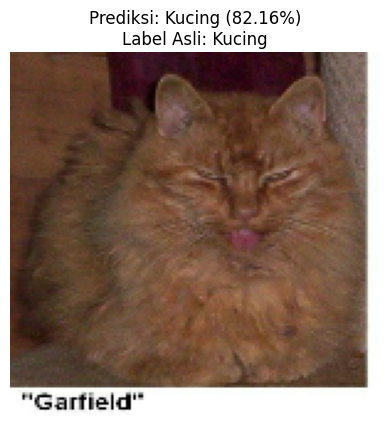

Label Asli     : Kucing
Prediksi Model : Kucing
Confidence     : 82.16%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# nama kelas
class_names = ['Kucing', 'Anjing']

# ambil 1 gambar dari test_data
for images, labels in test_data.take(1):

    sample_image = images[0]
    sample_label = labels[0]

    # prediksi model
    prediction = model.predict(tf.expand_dims(sample_image, axis=0))

    # probabilitas
    prob = prediction[0][0]

    # menentukan kelas prediksi
    if prob > 0.5:
        predicted_class = "Anjing"
        confidence = prob * 100
    else:
        predicted_class = "Kucing"
        confidence = (1 - prob) * 100

    # label asli
    actual_class = class_names[sample_label.numpy()]

    # tampilkan gambar
    plt.imshow(sample_image)
    plt.title(f"Prediksi: {predicted_class} ({confidence:.2f}%)\nLabel Asli: {actual_class}")
    plt.axis("off")
    plt.show()

    # hasil prediksi
    print("Label Asli     :", actual_class)
    print("Prediksi Model :", predicted_class)
    print("Confidence     :", f"{confidence:.2f}%")

In [ ]:
import os
import shutil

os.makedirs("submission", exist_ok=True)

shutil.copy("README.md", "submission/")
shutil.copy("best_model.keras", "submission/")
shutil.copy("model_cnn_kucing_anjing.h5", "submission/")
shutil.copy("requirements.txt", "submission/")

shutil.copytree("saved_model", "submission/saved_model", dirs_exist_ok=True)
shutil.copytree("tfjs_model", "submission/tfjs_model", dirs_exist_ok=True)
shutil.copytree("tflite", "submission/tflite", dirs_exist_ok=True)

print("Folder submission berhasil dibuat")

Folder submission berhasil dibuat


In [ ]:
!zip -r submission.zip submission

  adding: submission/ (stored 0%)
  adding: submission/model_cnn_kucing_anjing.h5 (deflated 12%)
  adding: submission/tflite/ (stored 0%)
  adding: submission/tflite/model.tflite (deflated 7%)
  adding: submission/tflite/label.txt (stored 0%)
  adding: submission/README.md (deflated 31%)
  adding: submission/tfjs_model/ (stored 0%)
  adding: submission/tfjs_model/group1-shard5of5.bin (deflated 6%)
  adding: submission/tfjs_model/group1-shard2of5.bin (deflated 6%)
  adding: submission/tfjs_model/model.json (deflated 89%)
  adding: submission/tfjs_model/group1-shard3of5.bin (deflated 6%)
  adding: submission/tfjs_model/group1-shard1of5.bin (deflated 7%)
  adding: submission/tfjs_model/group1-shard4of5.bin (deflated 7%)
  adding: submission/requirements.txt (deflated 13%)
  adding: submission/best_model.keras (deflated 12%)
  adding: submission/saved_model/ (stored 0%)
  adding: submission/saved_model/saved_model.pb (deflated 84%)
  adding: submission/saved_model/assets/ (stored 0%)
  add